## Importy

In [106]:
import warnings
from ultralytics import YOLO
warnings.filterwarnings("ignore")

import torch
import torch.nn.functional as F
import numpy as np
import cv2
from PIL import Image
from torchvision import transforms
import streamlit as st
import tempfile
import os
import sys

from segmentation.models import UNet
from segmentation.features import extract_features
from classification.models import CytologyClassifier
import joblib
import pandas as pd

In [107]:
unet_model_path = r"C:\Users\aleks\OneDrive\Documents\inzynierka\segmentation\models\unet\unet_cell_nucleus_0208.pth"
yolo_model_path = r'C:\Users\aleks\OneDrive\Documents\inzynierka\yolo_models\models\yolo_detector_2107_100_20_16_7682\weights\best.pt'
lightgbm_model_path = r'C:\Users\aleks\OneDrive\Documents\inzynierka\segmentation\models\best_model_LightGBM3.pkl'

CLASS_NAMES = ['HSIL', 'LSIL', 'NSIL']
vgg_weights = r'C:\Users\aleks\OneDrive\Documents\inzynierka\classification\classification_models\vgg16\32_0_0001_50_0608.pth'
ARCHITECTURE = 'vgg16'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [108]:
unet = UNet(in_channels=3, out_channels=2)
unet.load_state_dict(torch.load(unet_model_path, map_location=device))
unet.to(device).eval()

yolo = YOLO(yolo_model_path)

gbm_model = joblib.load(lightgbm_model_path)
label_encoder = gbm_model['label_encoder']

vgg_clf = CytologyClassifier(num_classes=len(CLASS_NAMES), architecture=ARCHITECTURE)
vgg_clf.load(vgg_weights)
vgg_clf.model.eval().to(device)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [109]:
def preprocess_image_unet(image_path):
    image = Image.open(image_path).convert("RGB")
    transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.ToTensor()
    ])
    tensor = transform(image)
    return image, tensor.unsqueeze(0)  

def predict_masks_unet(model, image_tensor, device, threshold_nuclei=0.3, threshold_cell=0.5):
    model.eval()
    with torch.no_grad():
        image_tensor = image_tensor.to(device)
        output = model(image_tensor)
        preds = torch.sigmoid(output).squeeze(0)  

        mask_cell = (preds[0] > threshold_cell).float().cpu().numpy()
        mask_nucleus = (preds[1] > threshold_nuclei).float().cpu().numpy()

    return [mask_cell, mask_nucleus]


def select_best_nucleus(mask, image_shape):
    contours, _ = cv2.findContours(mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return np.zeros_like(mask)

    h, w = image_shape
    center = np.array([w // 2, h // 2])

    best_score = -np.inf
    best_contour = None

    for cnt in contours:
        if len(cnt) < 5:
            continue
        ellipse = cv2.fitEllipse(cnt)
        (x, y), (MA, ma), angle = ellipse
        if MA == 0 or ma == 0:
            continue

        owalnosc = min(MA, ma) / max(MA, ma)
        nucleus_center = np.array([x, y])
        dist_to_center = np.linalg.norm(nucleus_center - center)

        score = owalnosc / (dist_to_center + 1e-5)
        if score > best_score:
            best_score = score
            best_contour = cnt

    output_mask = np.zeros_like(mask, dtype=np.uint8)
    if best_contour is not None:
        cv2.drawContours(output_mask, [best_contour], -1, 255, thickness=-1)

    return output_mask

def compute_iou(box1, box2):
    x1, y1, x2, y2 = box1
    xa1, ya1, xa2, ya2 = box2

    xi1, yi1 = max(x1, xa1), max(y1, ya1)
    xi2, yi2 = min(x2, xa2), min(y2, ya2)
    inter_area = max(0, xi2 - xi1) * max(0, yi2 - yi1)

    box1_area = (x2 - x1) * (y2 - y1)
    box2_area = (xa2 - xa1) * (ya2 - ya1)
    union_area = box1_area + box2_area - inter_area

    return inter_area / union_area if union_area > 0 else 0

def nms_keep_largest_box(boxes, iou_thresh=0.4):
    boxes = np.array(boxes)
    num_boxes = len(boxes)
    suppressed = np.zeros(num_boxes, dtype=bool)

    selected_indices = []

    for i in range(num_boxes):
        if suppressed[i]:
            continue
        overlaps = [i]
        for j in range(num_boxes):
            if i != j and not suppressed[j]:
                iou = compute_iou(boxes[i], boxes[j])
                if iou >= iou_thresh:
                    overlaps.append(j)
                    suppressed[j] = True
        areas = [(boxes[k][2] - boxes[k][0]) * (boxes[k][3] - boxes[k][1]) for k in overlaps]
        largest_idx = overlaps[np.argmax(areas)]
        selected_indices.append(largest_idx)
        suppressed[i] = True

    return selected_indices

def predict_gbm(pipe, label_encoder, input_features):
    feature_names = ['N', 'C', 'NCr', 'Np', 'Cp', 'NCp', 'MinA', 'MinAr', 'MaxA', 'MaxAr', 'Nar', 'Car', 'NCar', 'NExt', 'CExt', 'NCExt', 'NSol', 'CSol', 'NCs', 'EqN', 'EqC', 'NCEq', 'OrN', 'OrC', 'NCOr']
    try:
        X_new = pd.DataFrame([[input_features[feat] for feat in feature_names]], columns=feature_names)
    except KeyError as e:
        raise ValueError(f"Brakuje cechy w słowniku: {e}")

    y_pred_encoded = pipe.predict(X_new)
    predicted_class = label_encoder.inverse_transform(y_pred_encoded)[0]

    return predicted_class

classifier_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225])
])  # old version for RGB input

def predict_label(classifier, crop_np):
    image_tensor = classifier_transform(crop_np).unsqueeze(0).to(classifier.device)
    with torch.no_grad():
        output = classifier.model(image_tensor)
        probs = torch.softmax(output, dim=1)
        pred_idx = probs.argmax().item()
        return classifier.class_names[pred_idx], image_tensor

def fuse_probs(p1, p2, eps=1e-9):
    p = (p1+eps) * (p2+eps)
    return p / p.sum()

def preprocess_image_for_vgg(img: Image.Image) -> torch.Tensor:
    tfm = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])
    return tfm(img)

@torch.inference_mode()
def predict_vgg_probs(model_or_wrapper, crop: np.ndarray) -> np.ndarray:
    img_pil = Image.fromarray(crop).convert("RGB")
    x = preprocess_image_for_vgg(img_pil).unsqueeze(0).to(device)
    net = getattr(model_or_wrapper, "model", model_or_wrapper)
    logits = net(x)
    probs = F.softmax(logits, dim=1).squeeze(0).cpu().numpy()
    return probs


FEATURE_NAMES = ['N', 'C', 'NCr', 'Np', 'Cp', 'NCp', 'MinA', 'MinAr', 'MaxA', 'MaxAr',
                 'Nar', 'Car', 'NCar', 'NExt', 'CExt', 'NCExt', 'NSol', 'CSol', 'NCs',
                 'EqN', 'EqC', 'NCEq', 'OrN', 'OrC', 'NCOr']

def predict_gbm_probs(model, label_encoder, input_features: dict) -> np.ndarray:
    try:
        X_new = pd.DataFrame([[input_features[f] for f in FEATURE_NAMES]], columns=FEATURE_NAMES)
    except KeyError as e:
        raise ValueError(f"Brakuje cechy w słowniku: {e}")

    proba = model.predict_proba(X_new)  # <-- tu nie używaj model["model"]
    classes_model = list(label_encoder.classes_)   
    probs_aligned = np.zeros(len(CLASS_NAMES), dtype=np.float32)
    for i, cname in enumerate(CLASS_NAMES):
        if cname in classes_model:
            probs_aligned[i] = proba[0, classes_model.index(cname)]
        else:
            probs_aligned[i] = 0.0

    s = probs_aligned.sum()
    if s > 0:
        probs_aligned = probs_aligned / s
    return probs_aligned


In [110]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as patches 

def get_info(image_path, show_image=True):
    import matplotlib.pyplot as plt
    import matplotlib.patches as patches

    image = Image.open(image_path).convert("RGB")
    image_np = np.array(image)
    # image_np = apply_clahe(image_np, clip_limit=2.0, tile_grid_size=(8, 8), use_median=True, median_kernel=3)

    image = Image.open(image_path).convert("RGB")
    image_np = np.array(image)

    results = yolo(image_path, conf=0.25, iou=0.5, agnostic_nms=False)
    boxes_tensor = results[0].boxes.xyxy.cpu()
    classes_tensor = results[0].boxes.cls.cpu().int()

    boxes_array = boxes_tensor.numpy()
    keep_ids = nms_keep_largest_box(boxes_array, iou_thresh=0.4)

    boxes_tensor = boxes_tensor[keep_ids]
    classes_tensor = classes_tensor[keep_ids]

    cell_mask = (classes_tensor == 0) | (classes_tensor == 1) | (classes_tensor == 2)  # include HSIL_group if class 2
    boxes = boxes_tensor[cell_mask].numpy().astype(int)

    predict_classes_vgg = {}
    predict_classes = {}
    predict_fused = {}
    features_list = {}
    probs = {} 

    # Rysowanie bboxów na obrazie
    if show_image:
        fig, ax = plt.subplots(figsize=(10, 10))
        ax.imshow(image_np)
        for idx, (x1, y1, x2, y2) in enumerate(boxes):
            rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=2, edgecolor='lime', facecolor='none')
            ax.add_patch(rect)
            ax.text(x1, y1-5, str(idx), color='red', fontsize=12, weight='bold', bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))
        ax.set_axis_off()
        plt.show()

    for idx, (x1, y1, x2, y2) in enumerate(boxes):
        crop = image_np[y1:y2, x1:x2]
        if crop.size == 0:
            continue

        # Find YOLO class for this box
        yolo_class = None
        for i, box in enumerate(boxes_tensor.numpy().astype(int)):
            if np.array_equal(box, [x1, y1, x2, y2]):
                yolo_class = int(classes_tensor[i].item())
                break

        # If YOLO class is HSIL_group (assume class 2 or adjust as needed)
        if yolo_class == 1:
            predict_classes_vgg[idx] = 'HSIL/LSIL_group'
            continue

        with tempfile.NamedTemporaryFile(suffix='.png', delete=False) as tmp_crop:
            cv2.imwrite(tmp_crop.name, cv2.cvtColor(crop, cv2.COLOR_RGB2BGR))
            tmp_path = tmp_crop.name

        _, tensor = preprocess_image_unet(tmp_path)
        masks = predict_masks_unet(unet, tensor, device)
        mask_nucleus = cv2.resize(masks[1], (crop.shape[1], crop.shape[0]))
        best_nucleus = select_best_nucleus(mask_nucleus, crop.shape[:2])
        mask_cell = cv2.resize(masks[0], (crop.shape[1], crop.shape[0])) * 255

        # Skip if no nucleus detected
        if np.count_nonzero(best_nucleus) == 0:
            continue

        features = extract_features(best_nucleus, mask_cell)
        features_list[idx] = features
        predict_class = predict_gbm(gbm_model['model'], label_encoder, features)
        predict_classes[idx] = predict_class

        predict_class_vgg = predict_label(vgg_clf, crop)
        predict_classes_vgg[idx] = predict_class_vgg[0]

        probs_vgg = predict_vgg_probs(vgg_clf, crop)
        probs_xgb = predict_gbm_probs(gbm_model['model'], label_encoder, features)
        predict_class_fused = CLASS_NAMES[np.argmax(fuse_probs(probs_vgg, probs_xgb))]
        predict_fused[idx] = predict_class_fused
        probs[idx] = {
            'vgg': probs_vgg,
            'gbm': probs_xgb,
            'fused': fuse_probs(probs_vgg, probs_xgb)
        }
    
    all_indices = set(predict_classes_vgg.keys()) | set(predict_classes.keys()) | set(predict_fused.keys())
    rows = []
    for idx in sorted(all_indices):
        rows.append({
            "idx": idx,
            "predict_vgg": predict_classes_vgg.get(idx, None),
            "predict_gbm": predict_classes.get(idx, None),
            "predict_fused": predict_fused.get(idx, None)
        })

    df_preds = pd.DataFrame(rows)

    return features_list, predict_classes_vgg, predict_classes, predict_fused, probs, df_preds



image 1/1 C:\Users\aleks\OneDrive\Documents\inzynierka\data\LBC_slides\LSIL\pow 40\6b.bmp: 480x768 12 cells, 146.4ms
Speed: 3.1ms preprocess, 146.4ms inference, 1.0ms postprocess per image at shape (1, 3, 480, 768)
image 1/1 C:\Users\aleks\OneDrive\Documents\inzynierka\data\LBC_slides\LSIL\pow 40\6b.bmp: 480x768 12 cells, 146.4ms
Speed: 3.1ms preprocess, 146.4ms inference, 1.0ms postprocess per image at shape (1, 3, 480, 768)


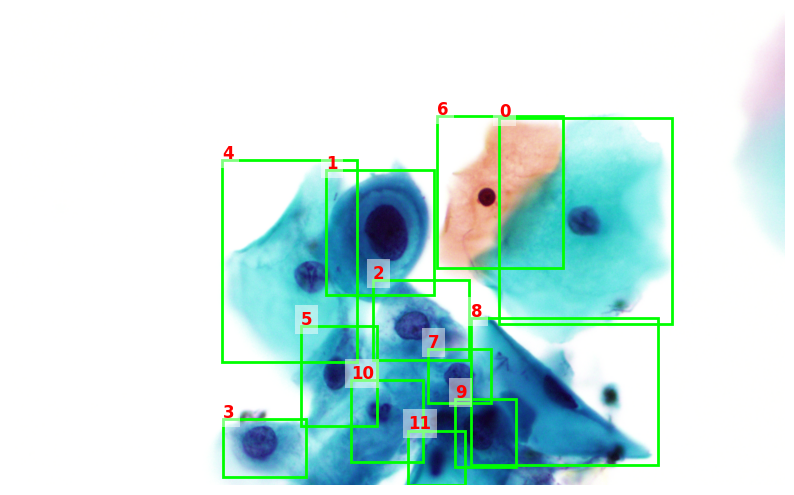

In [111]:
image_path = r'C:\Users\aleks\OneDrive\Documents\inzynierka\data\LBC_slides\LSIL\pow 40\6b.bmp'
features_list, predict_classes_vgg, predict_classes, probs_fused, probs, df  = get_info(image_path)

In [112]:
df

,idx,predict_vgg,predict_gbm,predict_fused
0,0,NSIL,NSIL,NSIL
1,1,LSIL,HSIL,LSIL
2,2,LSIL,LSIL,LSIL
3,3,HSIL,LSIL,LSIL
4,4,LSIL,LSIL,LSIL
5,5,LSIL,LSIL,LSIL
6,6,NSIL,NSIL,NSIL
7,7,LSIL,HSIL,HSIL
8,8,LSIL,NSIL,LSIL
9,9,HSIL,LSIL,LSIL



image 1/1 C:\Users\aleks\OneDrive\Documents\inzynierka\data\LBC_slides\NSIL\pow 40\61f.bmp: 480x768 12 cells, 67.7ms
Speed: 2.7ms preprocess, 67.7ms inference, 1.5ms postprocess per image at shape (1, 3, 480, 768)
image 1/1 C:\Users\aleks\OneDrive\Documents\inzynierka\data\LBC_slides\NSIL\pow 40\61f.bmp: 480x768 12 cells, 67.7ms
Speed: 2.7ms preprocess, 67.7ms inference, 1.5ms postprocess per image at shape (1, 3, 480, 768)


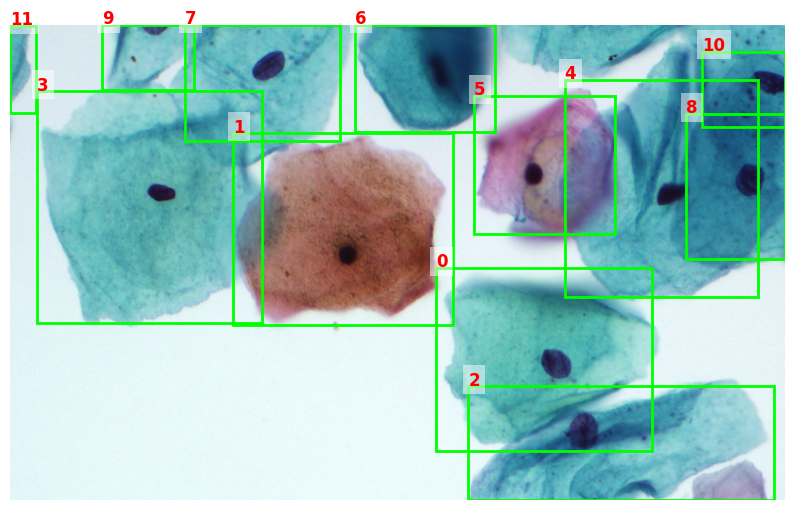

In [113]:
image_path = r'C:\Users\aleks\OneDrive\Documents\inzynierka\data\LBC_slides\NSIL\pow 40\61f.bmp'
features_list, predict_classes_vgg, predict_classes, probs_fused, probs, df = get_info(image_path)

In [114]:
df

,idx,predict_vgg,predict_gbm,predict_fused
0,0,NSIL,NSIL,NSIL
1,1,NSIL,NSIL,NSIL
2,2,LSIL,NSIL,LSIL
3,3,NSIL,NSIL,NSIL
4,4,NSIL,NSIL,NSIL
5,5,NSIL,NSIL,NSIL
6,6,LSIL,HSIL,LSIL
7,7,NSIL,LSIL,LSIL
8,8,LSIL,LSIL,LSIL
9,9,NSIL,LSIL,LSIL



image 1/1 C:\Users\aleks\OneDrive\Documents\inzynierka\data\LBC_slides\HSIL\pow 40\10b.bmp: 480x768 14 cells, 2 HSIL_groups, 73.0ms
Speed: 3.6ms preprocess, 73.0ms inference, 1.2ms postprocess per image at shape (1, 3, 480, 768)
image 1/1 C:\Users\aleks\OneDrive\Documents\inzynierka\data\LBC_slides\HSIL\pow 40\10b.bmp: 480x768 14 cells, 2 HSIL_groups, 73.0ms
Speed: 3.6ms preprocess, 73.0ms inference, 1.2ms postprocess per image at shape (1, 3, 480, 768)


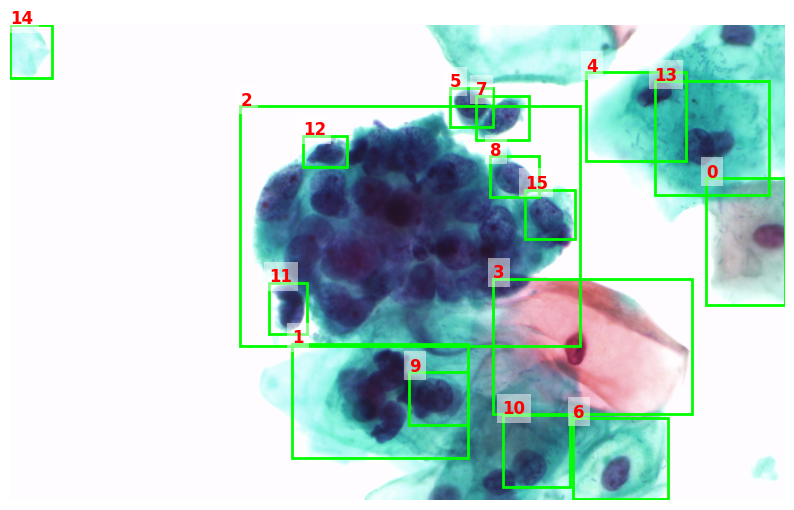

In [115]:
image_path = r'C:\Users\aleks\OneDrive\Documents\inzynierka\data\LBC_slides\HSIL\pow 40\10b.bmp'
features_list, predict_classes_vgg, predict_classes, probs_fused, probs, df = get_info(image_path)

In [116]:
df

,idx,predict_vgg,predict_gbm,predict_fused
0,0,LSIL,NSIL,LSIL
1,1,HSIL/LSIL_group,None,None
2,2,HSIL/LSIL_group,None,None
3,3,NSIL,NSIL,NSIL
4,4,LSIL,LSIL,LSIL
5,5,HSIL,HSIL,HSIL
6,6,LSIL,LSIL,LSIL
7,7,HSIL,HSIL,HSIL
8,8,HSIL,HSIL,HSIL
9,9,HSIL,HSIL,HSIL
